In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/bhanupratapbiswas/website-traffic-analysis/traffic.csv')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
df.shape

(226278, 9)

In [5]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.fillna('Unknown', inplace=True)

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,122567,122567,122567,122567,122567,122567,122567,122567,122567
unique,3,NaN,212,11993,2420,3255,3563,710,3839
top,pageview,NaN,United States,Unknown,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,73360,NaN,28664,8802,8288,8288,8288,8288,8288
mean,NaN,2021-08-21 20:21:13.673990656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2021-08-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2021-08-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2021-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2021-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2021-08-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df['event'].value_counts()

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

In [12]:
df['country'].value_counts().head(10)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64

In [13]:
df['artist'].value_counts().head(10)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64

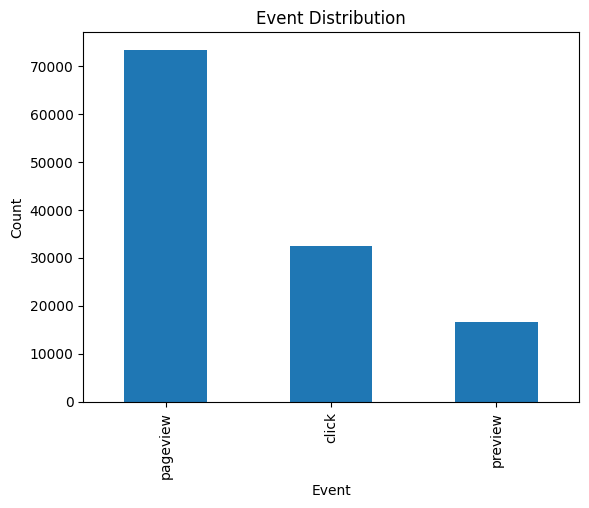

In [14]:
df['event'].value_counts().plot(kind='bar')

plt.title('Event Distribution')
plt.xlabel('Event')
plt.ylabel('Count')

plt.show()

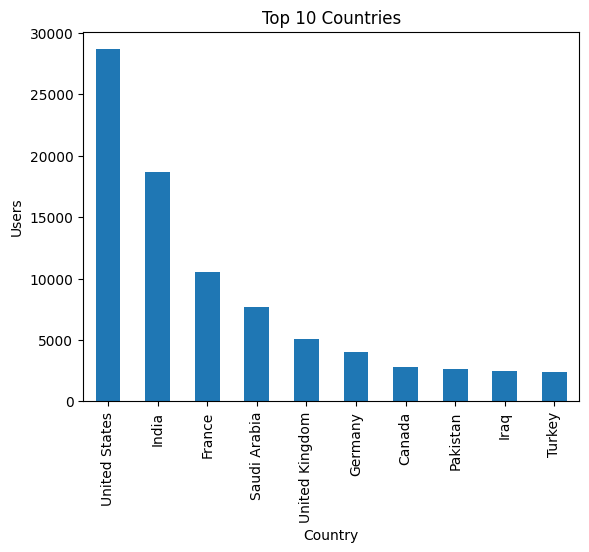

In [15]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Users')

plt.show()

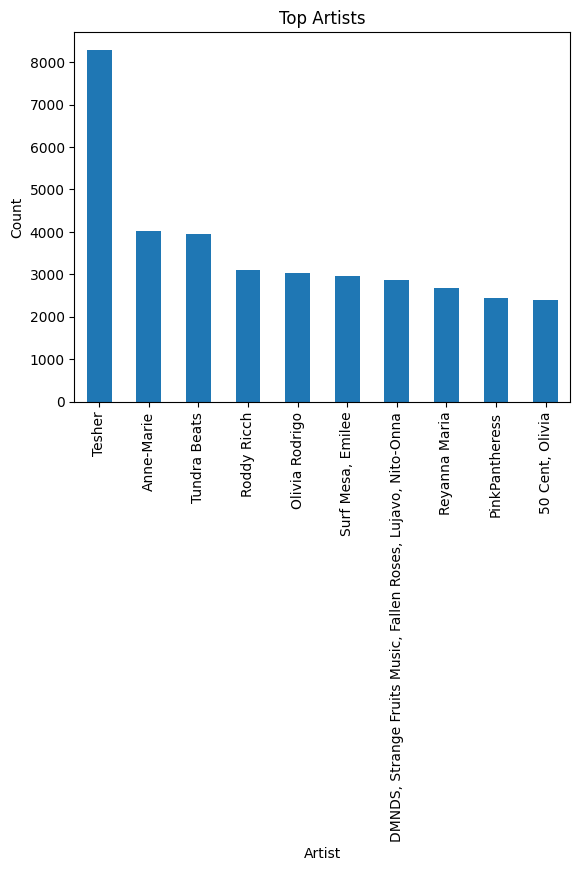

In [16]:
df['artist'].value_counts().head(10).plot(kind='bar')

plt.title('Top Artists')
plt.xlabel('Artist')
plt.ylabel('Count')

plt.show()

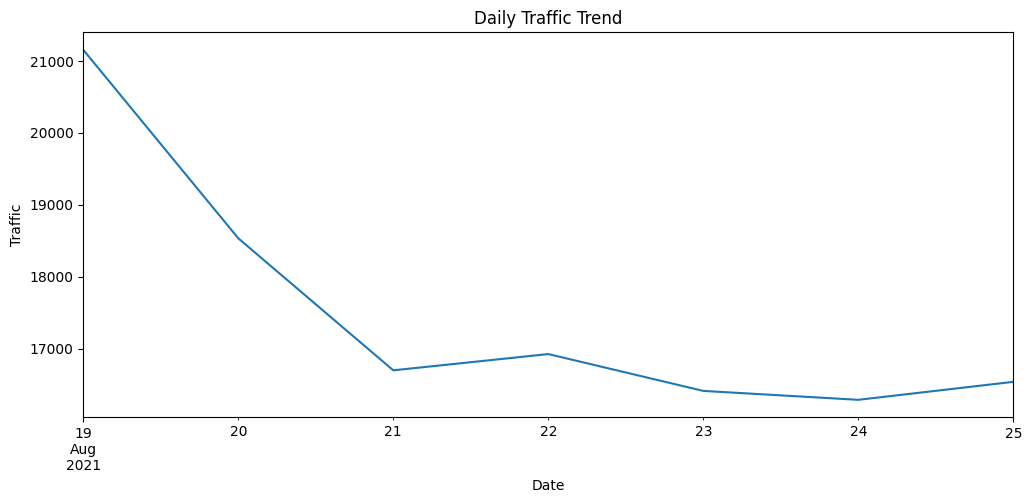

In [18]:
daily_traffic = df.groupby('date').size()

daily_traffic.plot(figsize=(12,5))

plt.title('Daily Traffic Trend')
plt.xlabel('Date')
plt.ylabel('Traffic')

plt.show()

In [19]:
df['country'].value_counts().head(5)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Name: count, dtype: int64

In [20]:
df['artist'].value_counts().head(10)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64

In [21]:
df['event'].value_counts()

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

In [22]:
df['city'].value_counts().head(10)

city
Unknown        8802
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64

In [23]:
import sqlite3

In [24]:
conn = sqlite3.connect(':memory:')

In [25]:
df.to_sql('traffic_data', conn, index=False, if_exists='replace')

122567

In [26]:
query = """
SELECT country, COUNT(*) as total
FROM traffic_data
GROUP BY country
ORDER BY total DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,country,total
0,United States,28664
1,India,18689
2,France,10565
3,Saudi Arabia,7682
4,United Kingdom,5095
5,Germany,4017
6,Canada,2784
7,Pakistan,2633
8,Iraq,2444
9,Turkey,2399


In [27]:
query = """
SELECT artist, COUNT(*) as total
FROM traffic_data
GROUP BY artist
ORDER BY total DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,artist,total
0,Tesher,8288
1,Anne-Marie,4029
2,Tundra Beats,3951
3,Roddy Ricch,3107
4,Olivia Rodrigo,3037
5,"Surf Mesa, Emilee",2956
6,"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",2865
7,Reyanna Maria,2675
8,PinkPantheress,2446
9,"50 Cent, Olivia",2390


In [28]:
query = """
SELECT event, COUNT(*) as total
FROM traffic_data
GROUP BY event
ORDER BY total DESC;
"""

pd.read_sql(query, conn)

,event,total
0,pageview,73360
1,click,32499
2,preview,16708


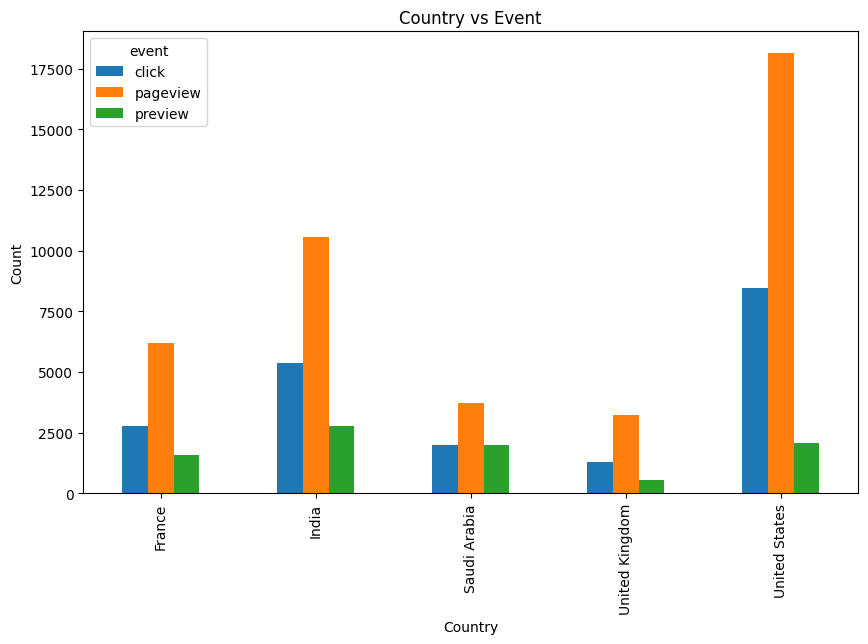

In [29]:
top_countries = df['country'].value_counts().head(5).index

filtered = df[df['country'].isin(top_countries)]

pd.crosstab(filtered['country'], filtered['event']).plot(kind='bar', figsize=(10,6))

plt.title('Country vs Event')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

# Dashboard KPIs

- Total Website Events
- Total Countries
- Top Artists
- Most Active Cities
- Daily Traffic Trend
- Most Common Event Type

# Conclusion

The EDA project successfully identified traffic patterns, top countries, artists, and user engagement trends from the website traffic dataset. SQL queries and visualizations helped generate business insights for decision-making.

In [30]:
df.to_csv('eda_cleaned_traffic.csv', index=False)

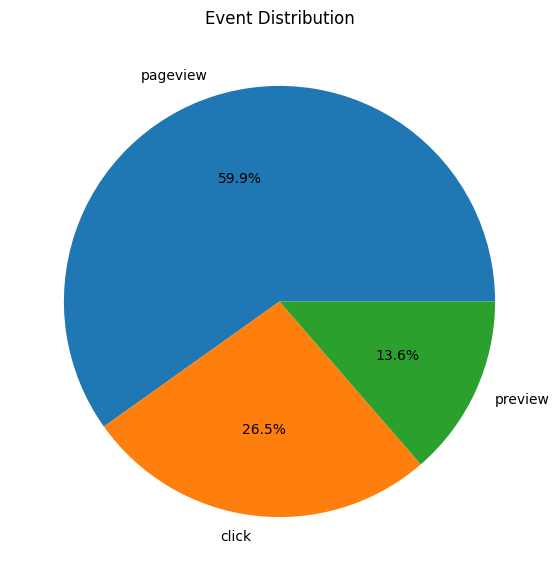

In [31]:
df['event'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Event Distribution')
plt.ylabel('')

plt.show()